# Create LDA for Brandon Sanderson Corpus

## Install Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF

In [2]:
sns.set_theme(style="white")
pio.renderers.default = "notebook"

#### Set Model Parameters

In [3]:
model_type = 'lda'
colors = 'YlGnBu'

In [4]:
OHCO = ['title', 'chapter_id', 'paragraph_id', 'sent_id', 'token_id']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = CHAP

## Get Data

In [5]:
directory_path  = 'C:/Users/mason/Box/Text As Data Final/Output'
TOKENS = pd.read_csv(f"{directory_path}/BrandonSanderson_CORPUS.csv", index_col=0).set_index(OHCO)
TOKENS.head()

token_str term_str  \
title             chapter_id paragraph_id sent_id token_id                      
A Memory of Light 0          0            0       0              The      the   
                                                  1            Wheel    wheel   
                                                  2               of       of   
                                                  3             Time     time   
                                                  4            turns    turns   

                                                            pos pos_group  
title             chapter_id paragraph_id sent_id token_id                 
A Memory of Light 0          0            0       0          DT        DT  
                                                  1         NNP        NN  
                                                  2          IN        IN  
                                                  3         NNP        NN  
                                                  4         NNS        NN

## Convert to a `DOCS` table filtering for Nouns

In [6]:
DOCS = TOKENS[TOKENS.pos.str.match(r'^(NN(?!P)|VB|JJ|RB)')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str, x)))\
    .to_frame()\
    .rename(columns={'term_str': 'doc_str'})
DOCS.head()


doc_str
title             chapter_id                                                   
A Memory of Light 0           turns come pass leaving memories become legend...
                  1           pevara did very best pretend was not terrified...
                  2           have indeed patched differences said sitting c...
                  3           was end said sitting wall feel emotions sat st...
                  4           al awoke drew deep breath slipped blankets ten...

## Create Vector Space

In [7]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS)
custom_stops = [
    'know', 'asked', 'think', 'people', 'man', 'eyes', 'make', 
    'going', 'want', 'need', 'right', 'got', 'good', 'look', 
    'long', 'away', 'men', 'woman', 'felt', 'did', 'didn', 'don',
    'll', 've', 're', 'nt'
]
my_stop_words.extend(custom_stops)

In [8]:
count_engine = CountVectorizer(max_df = 0.25, min_df=10, stop_words=my_stop_words, ngram_range=(1, 2))
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

aback  abandon  abandoned  \
title                          chapter_id                              
A Memory of Light              0               0        0          1   
                               1               0        1          0   
                               2               0        0          0   
                               3               0        0          0   
                               4               0        0          0   
...                                          ...      ...        ...   
Words of Radiance              4               0        0          2   
                               5               0        0          0   
                               6               0        0          0   
                               7               0        0          0   
Yumi and the Nightmare Painter 0               0        0          0   

                                           abandoning  abashed  abilities  \
title                          chapter_id                                   
A Memory of Light              0                    0        0          1   
                               1                    0        0          0   
                               2                    0        0          0   
                               3                    0        0          0   
                               4                    0        0          0   
...                                               ...      ...        ...   
Words of Radiance              4                    0        0          1   
                               5                    0        0          0   
                               6                    0        0          0   
                               7                    0        0          2   
Yumi and the Nightmare Painter 0                    1        0          0   

                                           ability  able escape  able hear  \
title                          chapter_id                                    
A Memory of Light              0                 1            0          0   
                               1                 0            0          0   
                               2                 1            0          0   
                               3                 0            0          0   
                               4                 0            0          0   
...                                            ...          ...        ...   
Words of Radiance              4                 0            0          0   
                               5                 0            0          0   
                               6                 0            0          0   
                               7                 1            0          0   
Yumi and the Nightmare Painter 0                 0            0          0   

                                           able help  ...  youth  youthful  \
title                          chapter_id             ...                    
A Memory of Light              0                   0  ...      2         0   
                               1                   0  ...      0         0   
                               2                   0  ...      0         0   
                               3                   0  ...      0         0   
                               4                   0  ...      1         0   
...                                              ...  ...    ...       ...   
Words of Radiance              4                   0  ...      0         0   
                               5                   0  ...      0         0   
                               6                   0  ...      0         0   
                               7                   0  ...      0         0   
Yumi and the Nightmare Painter 0                   0  ...      0         0   

                                           youths  youyou  zephyr  \
title

## Generate Model

In [9]:
n_topics = 15
max_iter = 100
n_top_terms = 10
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [10]:
if model_type == 'lda':
    topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
elif model_type == 'nmf':
    topic_engine = NMF(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

## `THETA` table

In [11]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

title,Rhythm of War,The Lost Metal,Warbreaker,Elantris,The Wheel of Time,The Lost Metal,Tress of the Emerald Sea,The Bands of Mourning,The Lost Metal,Oathbringer
chapter_id,12,66,15,16,49,42,38,22,38,30
topic_id,,,,,,,,,,
T00,0.000098,0.000214,0.000084,0.000076,0.000089,0.059422,0.000156,0.000138,0.000169,0.044865
T01,0.168335,0.867105,0.076099,0.000076,0.000089,0.590550,0.350218,0.664938,0.584586,0.070285
T02,0.000098,0.000214,0.086012,0.072469,0.573313,0.000171,0.000156,0.000138,0.000169,0.000051
T03,0.000098,0.000214,0.000084,0.002114,0.022322,0.000171,0.515767,0.000138,0.000169,0.000051
T04,0.000098,0.032940,0.000084,0.000076,0.105255,0.000171,0.000156,0.000138,0.007228,0.078242
T05,0.000098,0.000214,0.000084,0.102056,0.000089,0.000171,0.000156,0.038434,0.000169,0.000051
T06,0.000098,0.000214,0.000084,0.000076,0.000089,0.000171,0.000156,0.000138,0.000169,0.089581
T07,0.047695,0.000214,0.000084,0.000076,0.004223,0.000171,0.052410,0.000138,0.000169,0.088967


#### Save Theta Table

In [12]:
THETA.to_csv(f"{directory_path}/BrandonSanderson_THETA.csv")

## PHI

In [13]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,uncharacteristically,said wasn,fan,answers,instruction,traveled,come fight,happened said,trusting,gazed
topic_id,,,,,,,,,,
T00,0.066667,1.854758,1.418045,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T01,0.066667,11.157231,8.153635,39.906669,0.066667,0.066667,0.066667,6.069923,1.098379,4.677496
T02,0.066667,4.272129,1.194933,1.374948,0.066667,17.580177,0.066667,2.821185,0.066667,0.066667
T03,0.066667,5.890302,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066668
T04,0.066667,8.398144,0.066667,0.066667,0.066667,3.611989,0.066667,0.066667,2.201396,4.993180
T05,4.133994,0.066667,0.066667,1.519579,0.066667,2.557018,0.066667,5.036727,1.192107,0.066667
T06,0.066667,1.192111,0.066667,2.876216,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667
T07,0.066667,0.066667,0.066667,2.324227,0.066667,3.933950,0.066667,1.117575,2.462778,0.066667
T08,0.066667,0.066667,0.066667,1.961632,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667


#### Save PHI table

In [14]:
PHI.to_csv(f"{directory_path}/BrandonSanderson_PHI.csv")

## Topics

In [15]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,gun tunnel steel mobile hole powers team enfor...
T01,gun ship train governor bubble speed rusts pla...
T02,cloak village inn gleeman al road trees sleep ...
T03,ship spores captain tress deck crew vines isla...
T04,camp gateway tent bloody weave wolf weaves dre...
T05,lady duke priest gyorn crowd throne lord princ...
T06,shallan spheres drawing hallway safehand books...
T07,bridge storm spear parshmen bridgemen slave ch...
T08,book emperor stamp seal soul art painting book...


## Topics by Doc Weight

#### Mean

In [16]:
TOPICS['doc_weight_mean'] = THETA.mean()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_mean', ascending=False).head(5).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_24640\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_24640\1845078788.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq
topic_id,,,
T01,gun ship train governor bubble speed rusts planet car waxillium,0.227892,0.180120
T12,priests servants palace children god cup gods eyebrow year smiling,0.164816,0.157393
T09,skaa mists street soldier rope backward pushing steel jumped bones,0.103638,0.120205
T02,cloak village inn gleeman al road trees sleep horses wolves,0.083355,0.110781
T10,lord creatures sule lord said elantrian majesty brother creature palace said quietly,0.067862,0.073806


#### Sum

In [17]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\mason\AppData\Local\Temp\ipykernel_24640\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\mason\AppData\Local\Temp\ipykernel_24640\2717084757.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_mean,term_freq,doc_weight_sum
topic_id,,,,
T01,gun ship train governor bubble speed rusts planet car waxillium,0.227892,0.180120,148.129610
T12,priests servants palace children god cup gods eyebrow year smiling,0.164816,0.157393,107.130129
T09,skaa mists street soldier rope backward pushing steel jumped bones,0.103638,0.120205,67.364967
T02,cloak village inn gleeman al road trees sleep horses wolves,0.083355,0.110781,54.180786
T10,lord creatures sule lord said elantrian majesty brother creature palace said quietly,0.067862,0.073806,44.110075
T04,camp gateway tent bloody weave wolf weaves dream valley dragons,0.059944,0.086071,38.963596
T03,ship spores captain tress deck crew vines island sailors sea,0.057635,0.036528,37.462865
T08,book emperor stamp seal soul art painting books writing reading,0.045488,0.031130,29.566906
T11,spren tower fused storms fabrial beads storm sphere shallan humans,0.041640,0.044262,27.065841


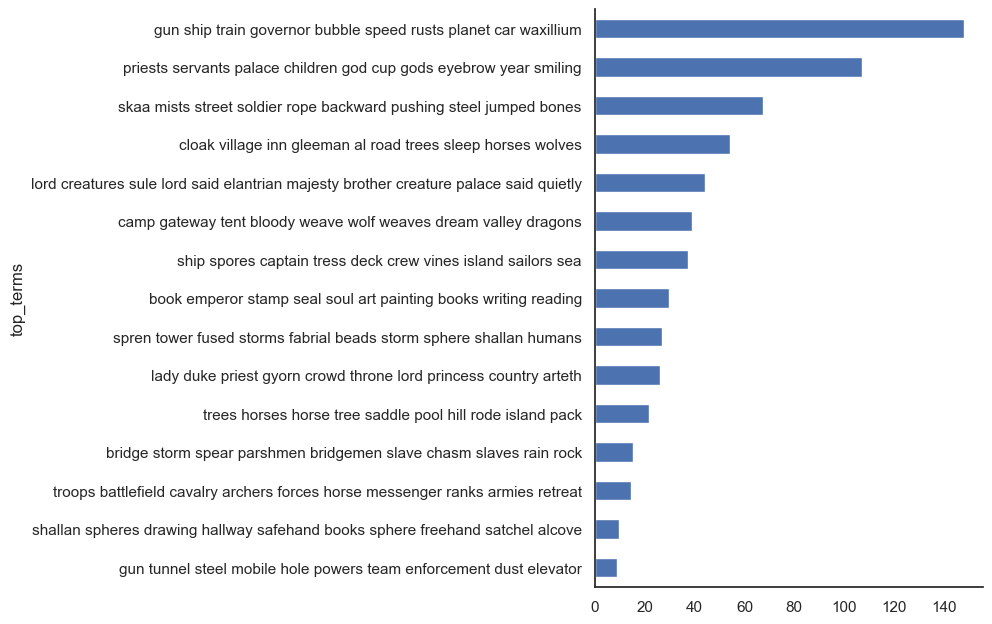

In [18]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

## Topics by Book

In [19]:
TOPIC_BOOK = THETA.groupby('title').mean()
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

title,A Memory of Light,Arcanum Unbounded,Elantris,Isles of the Emberdark,Oathbringer,Rhythm of War,Shadows of Self,Steelheart,The Aether of Night,The Alloy of Law,The Bands of Mourning,The Final Empire,The Hero of Ages,The Lost Metal,The Sunlit Man,The Way of Kings,The Well of Ascension,The Wheel of Time,Towers of Midnight,Tress of the Emerald Sea,Warbreaker,Wind and Truth,Words of Radiance,Yumi and the Nightmare Painter
topic_id,,,,,,,,,,,,,,,,,,,,,,,,
T00,0.001475,0.029523,0.004945,0.015516,0.006023,0.002957,0.007006,0.482104,0.000124,0.020415,0.002148,0.038822,0.000315,0.015860,0.000172,0.015252,0.000632,0.000575,0.000087,0.005622,0.027631,0.000148,0.000223,0.000392
T01,0.005366,0.085473,0.014672,0.232405,0.043068,0.101181,0.561058,0.249095,0.000124,0.570862,0.638820,0.031192,0.013377,0.676173,0.715466,0.029347,0.017278,0.001934,0.008926,0.277346,0.023862,0.054774,0.019394,0.419453
T02,0.053673,0.004041,0.016366,0.014064,0.019237,0.001654,0.013462,0.006198,0.004092,0.006735,0.022466,0.014016,0.024526,0.006510,0.005362,0.032615,0.025770,0.765797,0.135803,0.008714,0.070202,0.004363,0.071819,0.076190
T03,0.001205,0.000411,0.006049,0.030473,0.002692,0.005248,0.004822,0.000032,0.005090,0.006112,0.010717,0.006157,0.002799,0.006582,0.006431,0.047952,0.000632,0.036655,0.000429,0.464139,0.008401,0.005374,0.089340,0.043188
T04,0.495199,0.000411,0.028485,0.020964,0.033938,0.013597,0.015665,0.015663,0.009731,0.000405,0.004468,0.006157,0.014728,0.008796,0.038799,0.032753,0.001812,0.026224,0.301097,0.015354,0.021236,0.009997,0.052064,0.000392
T05,0.000130,0.000411,0.281623,0.010378,0.003925,0.007240,0.038760,0.000032,0.066443,0.004941,0.014005,0.016875,0.013841,0.007750,0.000172,0.015425,0.042017,0.004224,0.007566,0.018687,0.019438,0.001263,0.017735,0.000392
T06,0.000467,0.000411,0.000694,0.000268,0.102637,0.004138,0.005768,0.000032,0.000124,0.030829,0.001889,0.008346,0.140502,0.012966,0.000172,0.058780,0.000632,0.000657,0.006404,0.000230,0.003603,0.075181,0.049739,0.000392
T07,0.002117,0.000411,0.002498,0.003913,0.158106,0.053193,0.005028,0.000032,0.015427,0.000405,0.005666,0.006157,0.000315,0.002603,0.012310,0.266007,0.000632,0.000905,0.001194,0.006547,0.002934,0.000148,0.186700,0.000392
T08,0.001544,0.506691,0.018629,0.015958,0.152834,0.044687,0.011340,0.000032,0.017679,0.047185,0.008881,0.131848,0.033426,0.023310,0.020760,0.131017,0.011083,0.000521,0.012598,0.019947,0.065662,0.030550,0.051120,0.000392
